# One-Dimensional Burgers' Equation

In [38]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
%matplotlib inline

from functools import partial
import scipy.io
from scipy.stats import pearsonr
import scipy
from scipy.fft import fft, ifft
from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split
import time
import pickle
import random
import os

## DeepONet Class and RK4 Time-stepping

In [39]:
class BranchNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        
        init = nn.initializers.glorot_normal()
        for feat in self.features[:-1]:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        x = nn.Dense(self.features[-1])(x)
        return x

class TrunkNet(nn.Module):
    features: list

    @nn.compact
    def __call__(self, x):
        init = nn.initializers.glorot_normal()
        for feat in self.features:
            x = nn.Dense(feat,kernel_init = init)(x)
            x = nn.tanh(x)
        return x

class DeepONet(nn.Module):
    branch_features: list
    trunk_features: list

    @nn.compact
    def __call__(self, branch_input, trunk_input):
        branch_out = BranchNet(self.branch_features)(branch_input) 
        trunk_out = TrunkNet(self.trunk_features)(trunk_input)     
        output = jnp.einsum('bi,ti->bt', branch_out, trunk_out) 
        bias = self.param('bias', nn.initializers.zeros, (1,))
        output = output + bias
        return output

In [40]:
@jax.jit
def RK4(params,branch_x,trunk_x,dt = 0.01):
    
    curr_state = branch_x
    k1 = model_fn(params,curr_state,trunk_x)
    k2 = model_fn(params,curr_state+0.5*dt*k1,trunk_x)
    k3 = model_fn(params,curr_state+0.5*dt*k2,trunk_x)
    k4 = model_fn(params,curr_state+dt*k3,trunk_x)
    next_state = curr_state+(dt/6)*(k1+2*k2+2*k3+k4)
    return next_state

In [41]:
# Create the model
p = 60
branch_features = [101]+[100]*6+[p]
trunk_features = [101]+[100]*6+[p]
model = DeepONet(branch_features=branch_features, trunk_features=trunk_features)
model_fn = jax.jit(model.apply)

key = jax.random.PRNGKey(0)

## Data Preparation

In [42]:
dataset_burger = scipy.io.loadmat("/home/dnayak2/data_sgoswam4/Dibya/Datasets/1D_Burgers/Burger.mat")
outputs = dataset_burger['output']
n_samples = outputs.shape[0]
nx = outputs.shape[2]
nt = outputs.shape[1]
t = np.linspace(0,1,nt)
x = np.linspace(0,1,nx)
param_path = "ti_don_1d_burger.pkl" 
xspan = jnp.linspace(0,1,nx) 
grid = xspan.reshape(-1,1)
data_test = outputs
del outputs

with open(param_path, "rb") as f:
    params = pickle.load(f)


In [43]:
folder = "/home/rroy13/jax.venv/DeepONet/Coupling/1D_Burger"
os.makedirs(folder, exist_ok=True)

## Residual and Error Estimator

In [ ]:
## EMA-based error Estimator
@jax.jit
def burgers1d_res_error(params,u_curr, coll_points,eta_hist, nu=0.01): 
    
    u_curr_t = model_fn(params, u_curr, coll_points) 
    x = coll_points.flatten()
    ncoll = x.shape[0]
    u = u_curr.flatten()
    u_t = u_curr_t.flatten()
    u_x = jnp.gradient(u,x) 
    u_xx = jnp.gradient(u_x,x)
    res = u_t + u*u_x - nu*u_xx
    alpha = 0.1
    r = jnp.linalg.norm(res)/jnp.linalg.norm(u_curr)
    eta = (alpha*r+(1-alpha)*eta_hist)
    
    return res,eta

## Numerical Solver

In [45]:
def burgers1d(inits, tspan, s, visc): 

    n_samples = inits.shape[0] 
    s1 = s - 1 # exclude duplicate point at x=1 
    x = np.linspace(0, 1, s1, endpoint=False) 
    dx = x[1] - x[0] 
    dt = 1e-4 
    n_timesteps = int((tspan[1] - tspan[0]) / dt) 
    t_eval = np.linspace(tspan[0], tspan[1], n_timesteps + 1) 
    n_timesteps = len(t_eval)
    # Wavenumbers for FFT differentiation 
    k = 2 * np.pi * np.fft.fftfreq(s1, d=dx) 
    # RHS in Fourier space 
    def rhs(t, u_hat): 
        u = np.real(ifft(u_hat)) 
        u_squared = u**2 
        nonlin = -0.5j * k * fft(u_squared) 
        lin = -visc * k**2 * u_hat 
        return lin + nonlin 
    # Container for solutions (reconstructed to size s) 
    n_saved = int((n_timesteps + 1) / 100) + 1 
    uf_all = np.zeros((n_samples, n_saved, s)) 
    for n in range(n_samples): 
        u0 = inits[n, :-1] 
        # drop redundant endpoint 
        u0_hat = fft(u0) 
        sol = solve_ivp( rhs, tspan, u0_hat, method="RK45", t_eval=t_eval, rtol=1e-4, atol=1e-6 ) 
        uf = np.real(ifft(sol.y.T)) # (n_timesteps+1, s1) 
        # print(uf.shape)
        uf_down = uf[::100, :] # downsample in time 
        # print(uf_down.shape)
        # Reconstruct last periodic point explicitly for storage 
        uf_all[n, :, :-1] = uf_down 
        uf_all[n, :, -1] = uf_down[:, 0]
# enforce periodicity at x=1 = x=0 
    return uf_all

## Numerical Experimentation

### Correlation between EMA-based estimator and actual error

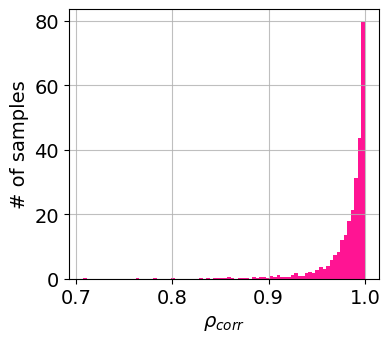

In [ ]:
## All Samples to compute pearson's coefficient
np.random.seed(40)
test_sample = np.random.choice(2500, size=2000, replace=False)
u_pred_model = np.zeros((len(test_sample),nt, nx))
eta_list_final = np.zeros((len(test_sample),nt-1))
l2error_list_final = np.zeros((len(test_sample),nt))

for k,ns in enumerate(test_sample):
    u_test = data_test[ns:ns+1,:nt]
    branch_test = data_test[ns:ns+1,0]
    trunk_test = grid
    u_pred_model[k,0,:] = branch_test
    u_curr = branch_test
    eta = 0
    eta_list = []
    for i in range(1, nt):
        u_curr = RK4(params,u_curr,trunk_test,dt = 0.01)
        res,eta = burgers1d_res_error(params,u_curr,trunk_test,eta)
        eta_list.append(eta)
        u_pred_model[k,i,:] = u_curr
        
    eta_list_final[k]=np.array(eta_list)
    l2_error = []
    for i in range(nt):
        l2_error.append(np.linalg.norm(u_pred_model[k,i,:] - u_test[0,i])/\
                         np.linalg.norm(u_test[0,i,:]))
   
    l2error_list_final[k] = np.array(l2_error)
    
    
r_list = [pearsonr(np.array(l2error_list_final[i,1:]),
                   np.array(eta_list_final[i]))[0] for i in range(len(test_sample))]
r_list = np.array(r_list)

plt.figure(figsize = (4,3.5))
plt.hist(r_list,density = True,bins = 80,color = 'deeppink')
# plt.title("Correlation between error estimator and actual error",fontsize = 14)
plt.xlabel(rf"$\rho_{{corr}}$",fontsize = 14)
plt.ylabel("# of samples",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.savefig(folder+"/pearson_coeff.pdf",dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
## Autoregressive Predictions
u_auto = np.load('u_pred_auto_1dburger.npz')['arr_0']

### Sample-by-sample study between AR-DON, TI-DON and ANCHOR (Ours)

In [90]:
# Randomly pick one sample
np.random.seed(40)
test_sample = np.random.choice(2500, size=1, replace=False)
print(f"Sample chosen: {test_sample}")

u_pred_auto = u_auto[test_sample]
u_test = data_test[test_sample,:nt]
branch_test = data_test[test_sample,0]
trunk_test = grid

sample_folder = f"/sample_{test_sample[0]}"
os.makedirs(folder+sample_folder, exist_ok=True)

Sample chosen: [2383]


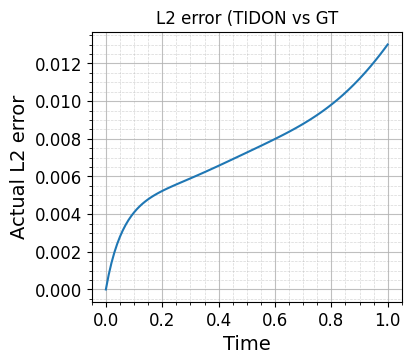

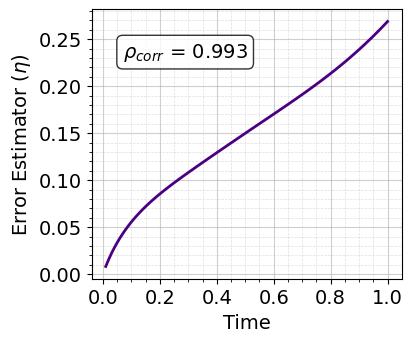

In [ ]:
u_pred_model = np.zeros((nt, nx))
u_pred_model[0,:] = branch_test
u_curr = branch_test
eta = 0
eta_list = []
for i in range(1, nt):
    ti = t[i]
    u_curr = RK4(params,u_curr,trunk_test,dt = 0.01)
    res,eta = burgers1d_res_error(params,u_curr,trunk_test,eta)
    eta_list.append(eta)
    u_pred_model[i,:] = u_curr

l2_error1 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i,:] - u_test[0,i,:])/np.linalg.norm(u_test[0,i,:]))

plt.figure(figsize =(4,3.5))
plt.plot(t,jnp.array(l2_error1),label = 'TIDON')
plt.title(f"L2 error (TIDON vs GT")#, Sample:{test_sample[0]}")
plt.xlabel("Time",fontsize = 14)
plt.ylabel("Actual L2 error",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.8)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.5)
plt.minorticks_on()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.legend()
# plt.savefig(folder+sample_folder+"/err_estm_l2_error.png",dpi=300)
plt.show()


plt.figure(figsize =(4,3.5))
plt.plot(t[1:],np.array(eta_list),color = 'indigo',lw = 2)
# plt.title(f"EMA-based Error Estimator")#, Sample:{test_sample[0]}")
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Error Estimator ($\eta$)",fontsize = 14)
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.text(0.1, 0.8, rf"$\rho_{{corr}}$ = {pearsonr(np.array(l2_error1[1:]),np.array(eta_list))[0]:.3f}",
    transform=plt.gca().transAxes,fontsize = 14,va='bottom',
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        alpha=0.8))
plt.minorticks_on()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.savefig(folder+sample_folder+"/err_estm.pdf",dpi = 300, bbox_inches='tight')
plt.show()

In [92]:
# Timing TI-DON
u_curr = branch_test
st = time.time()    
for i in range(1, nt):
    ti = t[i]
    u_curr = RK4(params,u_curr,trunk_test,dt = 0.01)
    u_pred_model[i,:] = u_curr
et = time.time()-st
print("TIDON Time: ",et)    

TIDON Time:  0.04759955406188965


In [93]:
## Timing Numerical Solver
st = time.time()
u_solver = burgers1d(branch_test, [0, 1.0],101,0.01)
et = time.time()-st
print("Solver Time: ", et) 

Solver Time:  0.14763689041137695


In [ ]:
## ANCHOR Framework
u_pred_coup= np.zeros((nt, nx))
u_pred_coup[0,:] = branch_test
u_curr = RK4(params,branch_test,trunk_test) #u_curr at i=1
i = 1
mark_model = []
mark_coup = []

eta_thres = 0

res,eta = burgers1d_res_error(params,branch_test,trunk_test,eta_hist=0)
rnorm0 = np.linalg.norm(res)
print("rnorm0:",rnorm0)
umax0 = np.max(branch_test)
print("umax0:",umax0)

st = time.time()
while i<nt:
    ti = t[i]
    res,eta = burgers1d_res_error(params,u_curr,trunk_test,eta) # computes residual at ith step using u_curr at ith step
    
    Kut = np.exp(-2*ti)*np.exp(-umax0)*umax0
    eta_thres = (Kut)
    print(f"estimator:{eta:.6f}|threshold:{eta_thres:.6f}")
    
    if eta<eta_thres:
        #print(f"tidon {i}")
        u_pred_coup[i,:] = u_curr
        mark_model.append(i)
        i+=1
        u_curr = RK4(params,u_curr,trunk_test)  # u_curr at i+1
    else:
        print(f"ns {i}")
        u_init = u_curr
        dt = 0.01
        nsteps = 11
        u_final = burgers1d(u_init, [0, dt*(nsteps-1)], 101, 0.01)
        if i+nsteps<nt:
            u_pred_coup[i:i+nsteps,:] = u_final[0]
        else:
            nsteps = nt-i
            u_pred_coup[i:i+nsteps,:] = u_final[0,:nsteps,:]
        mark_coup.append(list(range(i, i+nsteps)))
        i+=nsteps
        u_curr = u_pred_coup[i-1:i,:]
        res,eta = burgers1d_res_error(params,u_curr,trunk_test,eta_hist=0)
        u_curr = RK4(params,u_curr,trunk_test)

et = time.time()
print("ANCHOR Time:",et-st)    

rnorm0: 0.1328185
umax0: 0.22155752613075302
estimator:0.015498|threshold:0.174012
estimator:0.022034|threshold:0.170566
estimator:0.027941|threshold:0.167189
estimator:0.033324|threshold:0.163878
estimator:0.038265|threshold:0.160633
estimator:0.042831|threshold:0.157453
estimator:0.047076|threshold:0.154335
estimator:0.051045|threshold:0.151279
estimator:0.054774|threshold:0.148283
estimator:0.058295|threshold:0.145347
estimator:0.061632|threshold:0.142469
estimator:0.064809|threshold:0.139648
estimator:0.067844|threshold:0.136883
estimator:0.070753|threshold:0.134172
estimator:0.073551|threshold:0.131516
estimator:0.076250|threshold:0.128911
estimator:0.078863|threshold:0.126359
estimator:0.081399|threshold:0.123857
estimator:0.083868|threshold:0.121404
estimator:0.086277|threshold:0.119000
estimator:0.088635|threshold:0.116644
estimator:0.090947|threshold:0.114334
estimator:0.093220|threshold:0.112070
estimator:0.095459|threshold:0.109851
estimator:0.097670|threshold:0.107676
estim

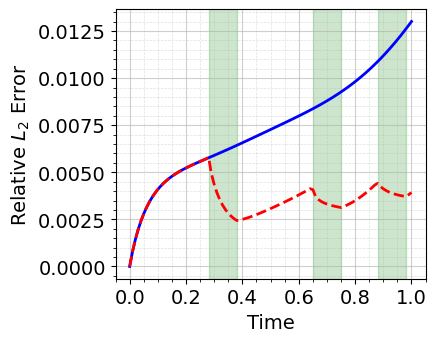

In [95]:
ts1 = [m[0] * 0.01 for m in mark_coup]
ts2 = [m[-1] * 0.01 for m in mark_coup]

# Plot of L2 error for each time step
l2_error1 = []
l2_error2 = []

for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i,:] - u_test[0,i,:])/np.linalg.norm(u_test[:,i,:]))
    l2_error2.append(np.linalg.norm(u_pred_coup[i,:] - u_test[0, i,:])/np.linalg.norm(u_test[:,i,:]))

plt.figure(figsize=(4,3.5))
plt.plot(t,np.array(l2_error1),color = 'b',label = 'TI-DON',lw = 2)
plt.plot(t,np.array(l2_error2),color = 'r',linestyle = '--',label = 'ANCHOR',lw = 2)
for x1,x2 in zip(np.array(ts1),np.array(ts2)):
    plt.axvspan(x1,x2,color = 'g',alpha = 0.2)
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Relative $L_2$ Error",fontsize = 14)
# plt.title(f"Relative $L_2$ Error")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# plt.legend()
plt.savefig(folder+sample_folder+"/coupled_L2_error.pdf",dpi = 300, bbox_inches='tight')
plt.show()


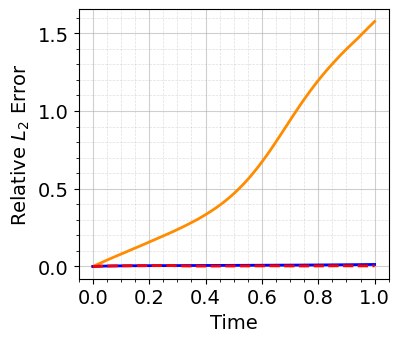

In [96]:
l2_error1 = []
l2_error2 = []
l2_error3 = []
for i in range(nt):
    l2_error1.append(np.linalg.norm(u_pred_model[i] - u_test[:,i])/np.linalg.norm(u_test[:,i]))
    l2_error2.append(np.linalg.norm(u_pred_coup[i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))
    l2_error3.append(np.linalg.norm(u_pred_auto[:,i] - u_test[:, i])/np.linalg.norm(u_test[:,i]))

plt.figure(figsize=(4,3.5))
plt.plot(t,np.array(l2_error3),color = 'darkorange',label = 'AR-DON',lw = 2)
plt.plot(t,np.array(l2_error1),color = 'b',label = 'TI-DON',lw = 2)
plt.plot(t,np.array(l2_error2),color = 'r', linestyle = '--',label = 'ANCHOR',lw = 2)
plt.xlabel("Time",fontsize = 14)
plt.ylabel(r"Relative $L_2$ Error",fontsize = 14)
# plt.title(f"Relative $L_2$ Error")
plt.grid(which='major', linestyle='-', axis = 'both', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', linestyle='--',axis = 'both', linewidth=0.5, alpha=0.4)
plt.minorticks_on()
# plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.savefig(folder+sample_folder+"/l2errors.pdf",dpi = 300, bbox_inches='tight')
plt.show()

## Plotting solutions and errors

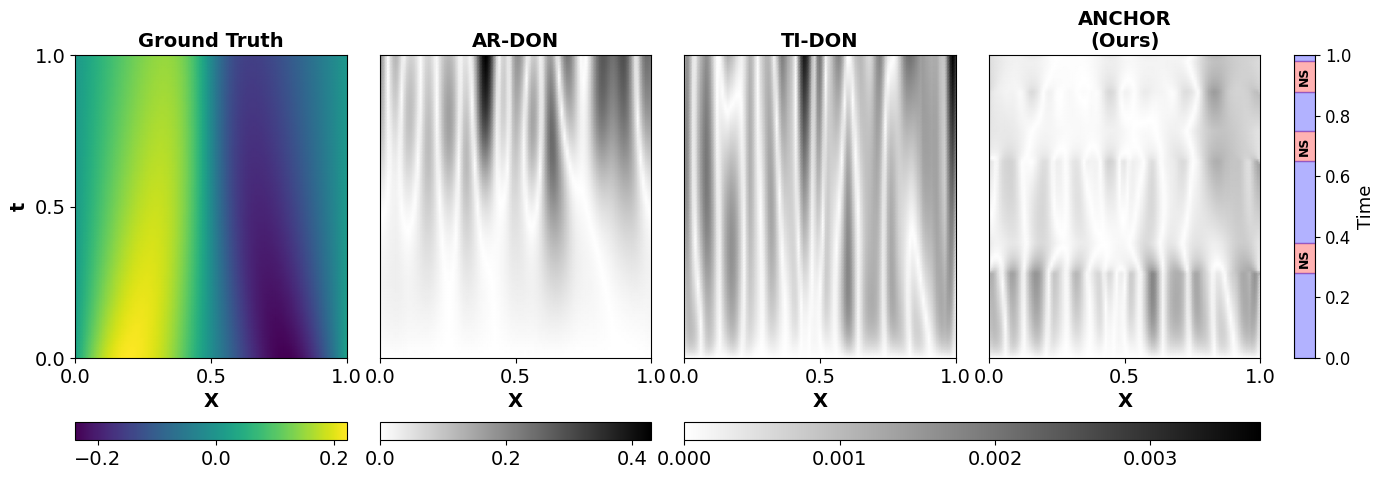

In [ ]:
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(
    nrows=2,
    ncols=5,
    height_ratios=[1, 0.06],
    width_ratios=[1, 1, 1, 1, 0.08],
    hspace=0.4,
    wspace=0.15
)

# Main Axes
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
ax_num = fig.add_subplot(gs[0, 4])

# Contours
pcm0 = axes[0].pcolormesh(x, t, u_test[0], cmap="viridis", shading="gouraud")
pcm1 = axes[1].pcolormesh(x, t, np.abs(u_pred_auto[0]-u_test[0]), cmap="binary", shading="gouraud")

err_tid = np.abs(u_pred_model-u_test[0])
err_tid_ns = np.abs(u_pred_coup-u_test[0])
vmin, vmax = err_tid.min(), max(err_tid.max(), err_tid_ns.max())

pcm2 = axes[2].pcolormesh(x, t, np.abs(u_pred_model-u_test[0]),
                          cmap="binary", shading="gouraud",
                          vmin=vmin, vmax=vmax)
pcm3 = axes[3].pcolormesh(x, t, np.abs(u_pred_coup-u_test[0]),
                          cmap="binary", shading="gouraud",
                          vmin=vmin, vmax=vmax)

titles = ["Ground Truth", "AR-DON", "TI-DON", "ANCHOR\n(Ours)"]
for ax, ti in zip(axes, titles):
    ax.set_title(ti, fontsize=14, fontweight="bold")
    ax.set_xlabel("X", fontsize=14,fontweight='bold')
    ax.tick_params(labelsize=14)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
for i, ax in enumerate(axes):
    if i == 0:  # leftmost contour
        ax.tick_params(left=True, labelleft=True)
    else:
        ax.tick_params(left=False, labelleft=False)
axes[0].set_ylabel("t", fontsize=14,fontweight='bold')

# Colorbars
# Individual colorbars
cb0 = fig.colorbar(pcm0, cax=fig.add_subplot(gs[1, 0]),
                   orientation="horizontal")
cb1 = fig.colorbar(pcm1, cax=fig.add_subplot(gs[1, 1]),
                   orientation="horizontal")
cb0.ax.tick_params(labelsize=14)
cb1.ax.tick_params(labelsize=14)
# Shared colorbar for last two
cb_shared = fig.colorbar(
    pcm2,
    cax=fig.add_subplot(gs[1, 2:4]),
    orientation="horizontal"
)
cb_shared.ax.tick_params(labelsize=14)
cb_shared.ax.xaxis.set_major_locator(mticker.MultipleLocator(0.001))
# cb_shared.set_label("Absolute Error", fontsize=13, fontweight="bold")

# Vertical Number line
ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_xticks([])

# NS (red)
for s, e in zip(ts1, ts2):
    ax_num.axhspan(s, e, color="red", alpha=0.3)
    ax_num.text(
        0.5, (s + e) / 2,
        "NS",
        ha="center", va="center",
        rotation=90,
        fontsize=9, fontweight="bold"
    )

# non-NS (gray)
intervals = []
if ts1[0] > 0:
    intervals.append((0, ts1[0]))
for i in range(len(ts1) - 1):
    if ts2[i] < ts1[i + 1]:
        intervals.append((ts2[i], ts1[i + 1]))
if ts2[-1] < 1:
    intervals.append((ts2[-1], 1))

for s, e in intervals:
    ax_num.axhspan(s, e, color="blue", alpha=0.3)

ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_xticks([])
ax_num.set_ylabel("Time", fontsize=13)
ax_num.yaxis.set_label_position("right")
ax_num.tick_params(axis='y', which='both', labelleft=False, labelright=True, right=True, left=False)
ax_num.tick_params(labelsize=12)

plt.savefig(folder+sample_folder+'/gt_errors.pdf',dpi = 300, bbox_inches='tight')
plt.show()

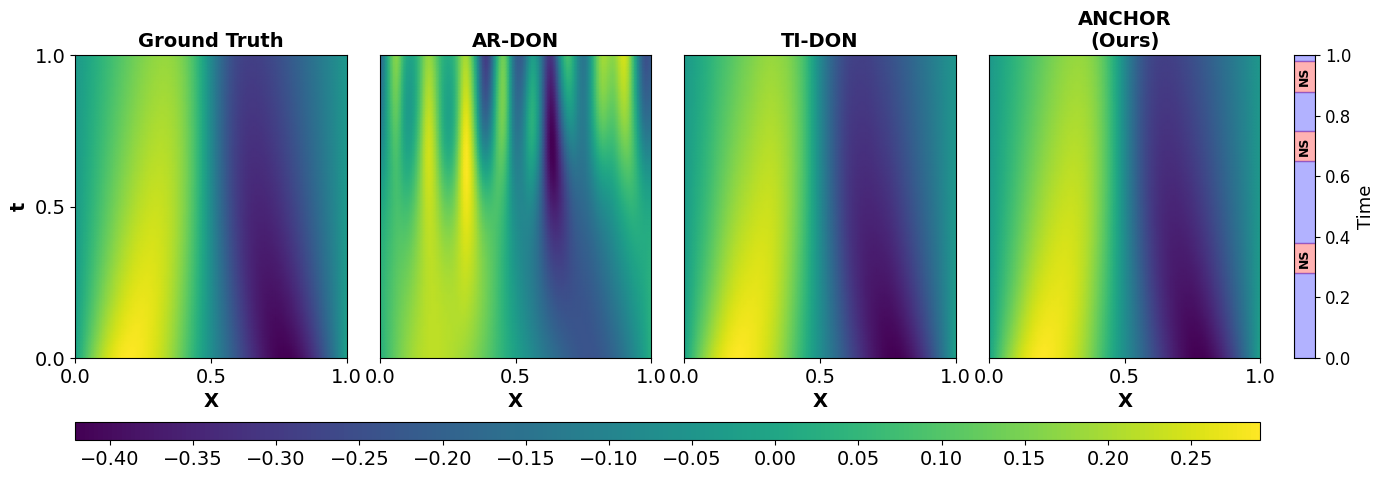

In [ ]:
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(
    nrows=2,
    ncols=5,
    height_ratios=[1, 0.06],
    width_ratios=[1, 1, 1, 1, 0.08],
    hspace=0.4,
    wspace=0.15
)

# Main Axes
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
ax_num = fig.add_subplot(gs[0, 4])

vmin = 0.0
vmax = u_test[0].max()

# Contours
pcm0 = axes[0].pcolormesh(
    x, t, u_test[0],
    cmap="viridis",
    shading="gouraud"
)

pcm1 = axes[1].pcolormesh(
    x, t, u_pred_auto[0],
    cmap="viridis",
    shading="gouraud"#,
    # vmin=vmin, vmax=vmax
)

pcm2 = axes[2].pcolormesh(
    x, t, u_pred_model,
    cmap="viridis",
    shading="gouraud"#,
    # vmin=vmin, vmax=vmax
)

pcm3 = axes[3].pcolormesh(
    x, t, u_pred_coup,
    cmap="viridis",
    shading="gouraud"#,
    # vmin=vmin, vmax=vmax
)

titles = ["Ground Truth", "AR-DON", "TI-DON", "ANCHOR\n(Ours)"]

for ax, ti in zip(axes, titles):
    ax.set_title(ti, fontsize=14, fontweight="bold")
    ax.set_xlabel("X", fontsize=14, fontweight="bold")
    ax.tick_params(labelsize=14)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))

for i, ax in enumerate(axes):
    if i == 0:
        ax.tick_params(left=True, labelleft=True)
    else:
        ax.tick_params(left=False, labelleft=False)

axes[0].set_ylabel("t", fontsize=14, fontweight="bold")

# Colorbar
cax = fig.add_subplot(gs[1, 0:4])
cb = fig.colorbar(pcm1, cax=cax, orientation="horizontal")

cb.ax.tick_params(labelsize=14)
cb.ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
# cb.set_label("Absolute Error", fontsize=14, fontweight="bold")

# Vertical Number line
ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_xticks([])
# ax_num.set_yticks([])

# NS (red)
for s, e in zip(ts1, ts2):
    ax_num.axhspan(s, e, color="red", alpha=0.3)
    ax_num.text(
        0.5, (s + e) / 2,
        "NS",
        ha="center", va="center",
        rotation=90,
        fontsize=9, fontweight="bold"
    )

# non-NS (gray)
intervals = []
if ts1[0] > 0:
    intervals.append((0, ts1[0]))
for i in range(len(ts1) - 1):
    if ts2[i] < ts1[i + 1]:
        intervals.append((ts2[i], ts1[i + 1]))
if ts2[-1] < 1:
    intervals.append((ts2[-1], 1))

for s, e in intervals:
    ax_num.axhspan(s, e, color="blue", alpha=0.3)

ax_num.set_xlim(0, 1)
ax_num.set_ylim(0, 1)
ax_num.set_xticks([])
ax_num.set_ylabel("Time", fontsize=13)
ax_num.yaxis.set_label_position("right")
ax_num.tick_params(axis='y', which='both', labelleft=False, labelright=True, right=True, left=False)
ax_num.tick_params(labelsize=12)

# FINALIZE
plt.savefig(
    folder + sample_folder + "/solutions.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()